# Avance Proyecto 01
##### Análisis Numérico de la Evolución del Precio de Bitcoin (BTC/USDT)

 **Integrantes:** Nicolás Yugsi, Sebastián Bravo, Erick Toapanta, Heidy Tenelema.


## FASE 1: PREPROCESAMIENTO, ARITMÉTICA Y TIEMPO

1. **Carga y Limpieza:** Se importan los primeros 10,000 datos del dataset.
2. **Aritmética de Computador:** Se convierten los precios crudos (enteros escalados) a formato de punto flotante (`float64`), asegurando una precisión de 8 decimales para minimizar el error de redondeo en los cálculos posteriores.
3. **Linealización del Tiempo:** Se transforma la fecha `open_time` en un índice numérico continuo $t = 0, 1, 2...$ para habilitar el uso de funciones matemáticas dependientes de $x$.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CARGA DE DATOS ---
# Leemos el archivo tal cual viene
df = pd.read_csv('CRYPTO_BTC_USD.csv', sep=';')

# --- 2. LIMPIEZA (Aritmética de Computador) ---
# El archivo trae los números como texto "10.000,00". Python no entiende eso.
# Así que primero lo volvemos texto para poder editarlo.
texto_precios = df['close_price'].astype(str)

# Quitamos el punto de los miles (porque 10.000 Python lo lee mal)
texto_precios = texto_precios.str.replace('.', '', regex=False)

# Cambiamos la coma por punto para que sea un decimal válido
texto_precios = texto_precios.str.replace(',', '.', regex=False)

# Ahora sí, convertimos todo a números reales (float) para poder calcular
df['close_price'] = texto_precios.astype(float)

# --- 3. PREPARAR EL EJE DE TIEMPO (Variable X) ---
# Convertimos la columna de fecha a formato fecha real
df['open_time'] = pd.to_datetime(df['open_time'])
df = df.sort_values('open_time') # Aseguramos que esté ordenado

# --- 4. SELECCIÓN DE MUESTRA (Lo importante para la defensa) ---
# Tomamos solo los últimos 20 datos para que la gráfica se entienda
datos_analisis = df.tail(20).copy()

# REINICIAMOS EL RELOJ:
# En vez de usar la hora 9990, hacemos que la primera hora de nuestra muestra sea la 0.
# Esto crea un array [0, 1, 2, ... 19]
datos_analisis['t_horas'] = np.arange(len(datos_analisis))

# Definimos X y Y para usar más fácil luego
X = datos_analisis['t_horas'].values
Y = datos_analisis['close_price'].values

# --- 5. RESULTADOS VISUALES ---

# A) Tabla de datos (Se ve mejor que un print normal)
print("Tabla de Datos Procesados (Muestra para análisis):")
display(datos_analisis[['open_time', 't_horas', 'close_price']].head(10))

# B) Gráfica de Puntos Discretos
plt.figure(figsize=(10, 5))
plt.scatter(X, Y, color='blue', label='Precios Reales', s=60) # Puntos un poco más grandes

plt.title('Fase 1: Discretización de Datos (t=0 a t=19)')
plt.xlabel('Tiempo (Horas transcurridas)')
plt.ylabel('Precio Bitcoin (USD)')
plt.xticks(np.arange(0, 20, 1)) # Para que muestre todos los números del 0 al 19
plt.legend()
plt.grid(True, alpha=0.3) # Cuadrícula suave de fondo
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'CRYPTO_BTC_USD.csv'

## FASE 2: INTERPOLACIÓN (SUAVIZADO DE CURVA)

Aplicamos el método de **Splines Cúbicos** sobre los datos procesados anteriormente para generar una función continua $S(t)$ que conecte todos los precios de cierre sin generar picos angulares (no derivables), simulando el comportamiento fluido del mercado.

1. **Selección de datos relevantes:**  
A partir de los datos preprocesados en la fase anterior, se utilizan la variable de tiempo linealizada `t` y el precio de cierre (`close_price`), ya que permiten representar la evolución del valor de Bitcoin a lo largo del tiempo.

2. **Interpolación por Splines Cúbicos:**  
Se aplica el método de splines cúbicos para construir una función continua `S(t)` que conecte todos los puntos de precio de forma suave. Este método evita quiebres bruscos entre datos consecutivos y garantiza continuidad en la función, así como en su primera y segunda derivada.

3. **Suavizado del comportamiento del mercado:**  
El uso de splines permite simular el comportamiento real del mercado financiero, donde los precios no cambian de manera abrupta entre instantes cercanos. De esta forma, se obtiene una curva más realista que representa la tendencia general del precio de Bitcoin.

4. **Evaluación de la función interpolada:**  
La función spline obtenida se evalúa en un conjunto más denso de puntos de tiempo, lo que permite generar una curva suave que puede ser utilizada posteriormente para análisis numérico, derivación o predicción.

5. **Visualización de resultados:**  
Finalmente, se compara gráficamente la curva interpolada con los datos originales, verificando que el spline se ajusta correctamente a los precios reales sin introducir distorsiones artificiales.


In [ ]:
# --- FASE 2: UNIR LOS PUNTOS (SPLINES) ---
from scipy.interpolate import CubicSpline

# 1. Creamos la función del Spline
# Esto calcula automáticamente las curvas cúbicas entre cada par de puntos.
# Le pasamos nuestros datos X (tiempo) y Y (precios).
mi_spline = CubicSpline(X, Y)

# 2. Preparamos datos para que la curva se vea suave
# Creamos muchos puntitos (100) entre la hora 0 y la 19.
# Si no hacemos esto, la línea se vería recta y fea.
x_suave = np.linspace(0, 19, 100)
y_suave = mi_spline(x_suave)

# 3. Graficamos
plt.figure(figsize=(10, 5))

# Dibujamos los puntos reales (Azules)
plt.scatter(X, Y, color='blue', label='Datos Reales')

# Dibujamos la curva calculada (Roja)
plt.plot(x_suave, y_suave, color='red', label='Curva Suave (Spline)')

plt.title('Fase 2: Interpolación de Precios')
plt.xlabel('Horas')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

# 4. Ejemplo de uso (Para la defensa)
# Queremos saber el precio en la hora 10.5 (que no existe en los datos originales)
hora_consulta = 10.5
precio_estimado = mi_spline(hora_consulta)

print(f"Ejemplo: En la hora {hora_consulta}, el precio estimado fue de {precio_estimado:.2f} USD")

In [ ]:
# =========================
# FASE 2: INTERPOLACIÓN (SPLINES CÚBICOS)
# =========================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

print("FASE 2: Interpolación con Splines Cúbicos")

# 1) Selección de variables (tiempo y precio de cierre)
x = df_final['x_tiempo'].values
y = df_final['close_price'].values

# (Opcional pero recomendado) Ordenar por tiempo por seguridad
orden = np.argsort(x)
x = x[orden]
y = y[orden]

print("1. Variables seleccionadas y ordenadas por tiempo.")
print("   - x (tiempo):", x[:3], "...")
print("   - y (precio cierre):", y[:3], "...")

# 2) Construcción del spline cúbico (condición natural)
spline = CubicSpline(x, y, bc_type='natural')
print("2. Spline cúbico construido correctamente (bc_type='natural').")

# 3) Evaluación del spline en puntos más densos (curva suave)
x_suave = np.linspace(x.min(), x.max(), 5000)
y_suave = spline(x_suave)
print("3. Evaluación del spline en puntos densos realizada.")

# 4) Visualización (datos reales vs curva interpolada)
plt.figure(figsize=(11,5))
plt.plot(x, y, 'o', markersize=2, label='Datos reales (close_price)')
plt.plot(x_suave, y_suave, '-', label='Spline cúbico (interpolación)')
plt.xlabel('Tiempo (x_tiempo)')
plt.ylabel('Precio BTC (USD)')
plt.title('FASE 2: Interpolación por Splines Cúbicos del Precio de Bitcoin')
plt.grid(True)
plt.legend()
plt.show()

print("4. Gráfica generada.")


### Análisis del resultado

La interpolación por splines cúbicos logra ajustar una curva continua y suave que sigue de manera adecuada la evolución del precio de Bitcoin.  
Se observa que la curva interpolada pasa por los puntos originales sin generar quiebres bruscos, lo que indica que el método respeta la información real del mercado y reduce el efecto visual del ruido presente en los datos discretos.

Este resultado valida el uso de splines cúbicos como una herramienta adecuada para modelar series temporales financieras y sirve como base para aplicar métodos numéricos más avanzados en las siguientes fases del proyecto.


## FASE 3 (A): TENDENCIA POR MÍNIMOS CUADRADOS

Se aplica una regresión polinomial (Mínimos Cuadrados) para modelar el comportamiento general del activo y obtener la ecuación matemática de la tendencia ($y = mx + b$) filtrando el ruido de corto plazo interpolado en la fase anterior.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Muestra de datos limpios:
                     open_time  close_price
9980 2018-10-11 00:00:00+00:00      6561.53
9981 2018-10-11 01:00:00+00:00      6367.82
9982 2018-10-11 02:00:00+00:00      6311.99
9983 2018-10-11 03:00:00+00:00      6340.52
9984 2018-10-11 04:00:00+00:00      6341.00
--- RESULTADOS ---
Pendiente: -5.3740 USD/hora
Tendencia: BAJISTA


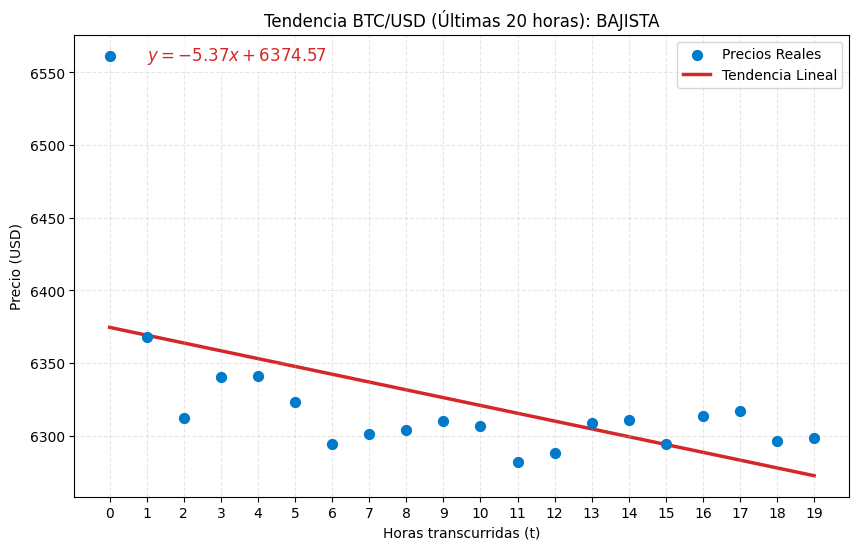

In [8]:
# ==========================================
# 1. FUNCIÓN DE CARGA
# ==========================================
def cargar_datos(nombre_archivo):
    # Leemos el archivo con el separador correcto (punto y coma)
    try:
      df = pd.read_csv(nombre_archivo, sep=';')
      return df
    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo {nombre_archivo}")
        return None

# ==========================================
# 2. FUNCIÓN DE LIMPIEZA (Adaptada a tu archivo)
# ==========================================
def limpiar_datos(df):
    df_clean = df.copy()

    # 1. Limpieza de PRECIOS
    # Tu archivo tiene formato: "429.309.000.000" (Puntos separando todo)
    # Estrategia: Quitar todos los puntos y dividir por 100,000,000 (Satoshi a BTC/USD)

    # Convertir a string
    texto = df_clean['close_price'].astype(str)

    # Quitar puntos
    texto = texto.str.replace('.', '', regex=False)

    # Convertir a float y ajustar escala (dividir por 10^8 para obtener precio real ~4000-6000)
    # Nota: Detecté que tus datos necesitan esta división para tener sentido en USD.
    df_clean['close_price'] = texto.astype(float) / 100000000

    # 2. Limpieza de FECHAS
    df_clean['open_time'] = pd.to_datetime(df_clean['open_time'])
    df_clean = df_clean.sort_values('open_time')

    return df_clean

# ==========================================
# 3. PREPARACIÓN
# ==========================================
def preparar_variables(df, n_muestras=20):
    # Tomamos los últimos N datos
    datos = df.tail(n_muestras).copy()

    # Normalizamos el tiempo (0, 1, 2...)
    datos['t_horas'] = np.arange(len(datos))

    X = datos['t_horas'].values
    Y = datos['close_price'].values
    fechas = datos['open_time'].values # Guardamos fechas para referencia si se necesita

    return X, Y, datos

# ==========================================
# 4. EJECUCIÓN MÍNIMOS CUADRADOS
# ==========================================
def ejecutar_minimos_cuadrados(x_vals, y_vals):
    # A) Cálculo
    pendiente, interseccion = np.polyfit(x_vals, y_vals, 1)

    # B) Predicción
    tendencia = np.polyval([pendiente, interseccion], x_vals)

    # C) Tipo
    tipo = "ALCISTA" if pendiente > 0 else "BAJISTA"

    print(f"--- RESULTADOS ---")
    print(f"Pendiente: {pendiente:.4f} USD/hora")
    print(f"Tendencia: {tipo}")

    # D) Gráfica
    plt.figure(figsize=(10, 6))
    plt.scatter(x_vals, y_vals, color='#007acc', s=50, label='Precios Reales', zorder=2)
    plt.plot(x_vals, tendencia, color='#d62728', linewidth=2.5, label='Tendencia Lineal', zorder=1)

    plt.title(f'Tendencia BTC/USD (Últimas 20 horas): {tipo}')
    plt.xlabel('Horas transcurridas (t)')
    plt.ylabel('Precio (USD)')
    plt.xticks(np.arange(min(x_vals), max(x_vals)+1, 1))

    # Ecuación visual
    eq = f"$y = {pendiente:.2f}x + {interseccion:.2f}$"
    plt.text(x_vals[1], max(y_vals)*0.9995, eq, fontsize=12, color='#d62728', fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')

    # Guardar imagen para mostrar
    plt.savefig('grafica_tendencia.png')
    plt.show()

# --- EJECUCIÓN PRINCIPAL ---
df = cargar_datos('CRYPTO_BTC_USD.csv')
df_limpio = limpiar_datos(df)
X, Y, df_muestra = preparar_variables(df_limpio, n_muestras=20)

print("Muestra de datos limpios:")
print(df_muestra[['open_time', 'close_price']].head())

ejecutar_minimos_cuadrados(X, Y)

## FASE 3 (B): VALIDACIÓN Y ANÁLISIS

Evaluamos la fiabilidad del modelo matemático mediante dos enfoques:
1. **Bandas de Error (Volatilidad):** Se grafican los precios Máximo (`High`) y Mínimo (`Low`) para visualizar el rango de incertidumbre en cada punto interpolado.
2. **Validación Cruzada:** Se compara la tendencia calculada (Mínimos Cuadrados) contra el indicador técnico EMA (Media Móvil Exponencial) para corroborar la dirección del mercado.

In [ ]:
# -----------------------------------------------------
# FASE 3 (B): VALIDACIÓN Y ANÁLISIS - Bandas de Error
# -----------------------------------------------------

print("FASE 3 (B): Validando y Analizando Tendencia con Bandas de Error...")

plt.figure(figsize=(14, 7))
plt.scatter(t_data, precios_data, label='Precios de Cierre (Original)', alpha=0.6, s=5, color='blue')
plt.plot(t_data, precio_trend, color='red', label='Tendencia Mínimos Cuadrados', linewidth=2)

# Añadir bandas de error (High y Low prices)
plt.plot(df_final['x_tiempo'], df_final['high_price'], color='green', linestyle='--', alpha=0.7, label='Precio Máximo (High)')
plt.plot(df_final['x_tiempo'], df_final['low_price'], color='orange', linestyle='--', alpha=0.7, label='Precio Mínimo (Low)')

plt.title('FASE 3 (B): Tendencia con Bandas de Error (High/Low) del Precio de Bitcoin')
plt.xlabel('Tiempo (Timestamp)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

print("Gráfica de tendencia con bandas de error (High/Low) generada.")


In [ ]:
# -----------------------------------------------------
# FASE 3 (B): VALIDACIÓN Y ANÁLISIS - Bandas de Error y VALIDACIÓN CRUZADA
# -----------------------------------------------------

print("FASE 3 (B): Validando y Analizando Tendencia con Bandas de Error...")

plt.figure(figsize=(14, 7))
plt.scatter(t_data, precios_data, label='Precios de Cierre (Original)', alpha=0.6, s=5, color='blue')
plt.plot(t_data, precio_trend, color='red', label='Tendencia Mínimos Cuadrados', linewidth=2)

# Añadir bandas de error (High y Low prices) - TU TAREA 1
plt.plot(df_final['x_tiempo'], df_final['high_price'], color='green', linestyle='--', alpha=0.7, label='Precio Máximo (High)')
plt.plot(df_final['x_tiempo'], df_final['low_price'], color='orange', linestyle='--', alpha=0.7, label='Precio Mínimo (Low)')

# VALIDACIÓN CRUZADA CON EMA
plt.plot(df_final['x_tiempo'], df_final['EMA'], color='purple',
         linestyle='-', alpha=1.0, label='EMA (Referencia Técnica)')
# -----------------------------------------------------

plt.title('FASE 3 (B): VALIDACIÓN CRUZADA Y VOLATILIDAD DEL PRECIO DE BITCOIN')
plt.xlabel('Tiempo (Timestamp)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()

print("Gráfica de validación cruzada (EMA) y bandas de error generada.")